Look at change rates of modern methane. Perhaps compare them to naive interpretation of paleo record.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant, fig_width_options
plt.rcParams.update(matplotlib_rcparams)
plt.rcParams['figure.dpi'] = 200

In [16]:
## load data
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_root)

obs_modern = pd.read_csv(data_dir / "raw" / "ch4_annmean_gl.csv", comment='#')

In [36]:
# calculate change over some lag
lag = 5
obs_modern["ch4_change"] = obs_modern["mean"].diff(periods=lag)

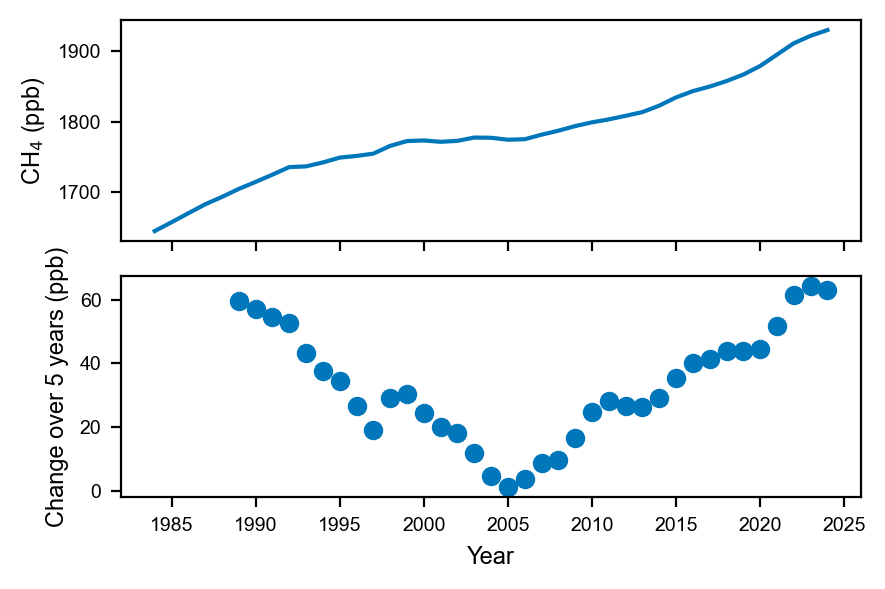

In [37]:
# plot obs and change
fig, axs = plt.subplots(2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True)

axs[0].plot(obs_modern["year"], obs_modern["mean"], color=colors_vibrant["blue"])
axs[0].set_ylabel("CH$_4$ (ppb)")

axs[1].plot(obs_modern["year"], obs_modern["ch4_change"], linestyle="", marker='o', color=colors_vibrant["blue"])
axs[1].set_ylabel(f"Change over {lag} years (ppb)")
axs[1].set_xlabel("Year")

plt.tight_layout()

In [38]:
## detrend linearly
ceoffs = np.polyfit(obs_modern["year"].dropna(), obs_modern["mean"].dropna(), deg=1)
trend = np.polyval(ceoffs, obs_modern["year"])
obs_modern["mean_detrended"] = obs_modern["mean"] - trend
obs_modern["ch4_change_detrended"] = obs_modern["mean_detrended"].diff(periods=lag)
ceoffs

array([ 5.68261324e+00, -9.60470059e+03])

Text(0.5, 0, 'Year')

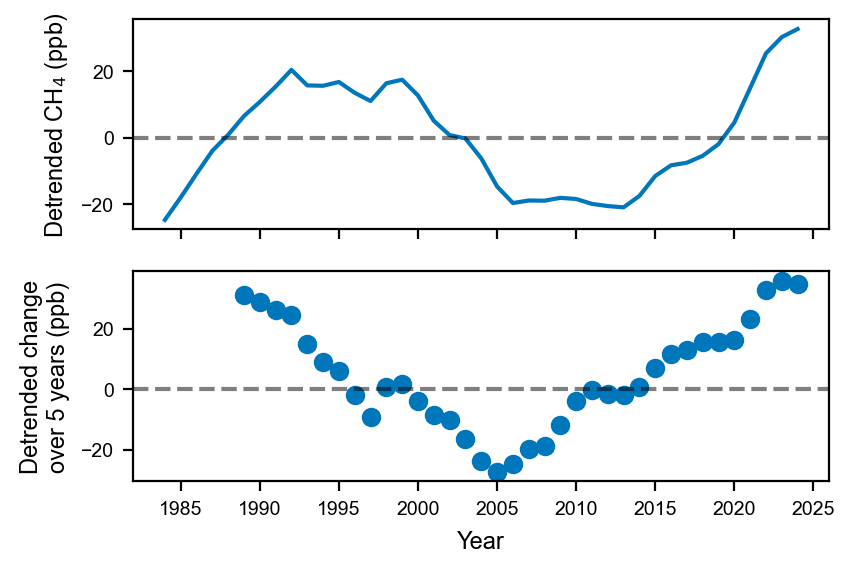

In [39]:
# plot detrended obs and change
fig, axs = plt.subplots(2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True)

axs[0].plot(obs_modern["year"], obs_modern["mean_detrended"], color=colors_vibrant["blue"])
axs[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[0].set_ylabel("Detrended CH$_4$ (ppb)")

axs[1].plot(obs_modern["year"], obs_modern["ch4_change_detrended"], linestyle="", marker='o', color=colors_vibrant["blue"])
axs[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axs[1].set_ylabel(f"Detrended change\nover {lag} years (ppb)")
axs[1].set_xlabel("Year")

# save detrended data

In [28]:
# save data
obs_modern_to_save = obs_modern[["year", "mean", "mean_detrended"]].dropna()
obs_modern_to_save = obs_modern_to_save.rename(columns={
    "mean": "ch4",
    "mean_detrended": "ch4_detrended"
})
save_dir = Path(cfg.paths.observations_cultivated)
obs_modern_to_save.to_csv(save_dir / "ch4_modern_detrended.csv", index=False)